In [2]:
import random
import torchaudio
from torchaudio import functional as FA
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import seaborn as sns
from evaluation_utils import _accuracy_end, _accuracy_start, _accuracy_centre, _accuracy_ordered, _accuracy_unordered, _accuracy_centre_flex, _accuracy_ordered_flex_centre

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
#content_encoder = HubertSoft(device=device)

# Модель

In [4]:
# Архитектура модели
class ClassificationModel(nn.Module):
    def __init__(self, inputsize, num_classes, dropout):
        super(ClassificationModel, self).__init__()
        self.inputsize = inputsize
        self.linear1 = nn.Linear(self.inputsize, 512)
        self.linear2 = nn.Linear(512, 256)
        self.linear3 = nn.Linear(256, 128)
        self.linear4 = nn.Linear(128, 64)
        self.final_start = nn.Linear(64, num_classes)
        self.final_center = nn.Linear(64, num_classes)
        self.final_end = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, element):
        a = self.relu(self.linear1(element))
        a = self.dropout(a)
        a = self.relu(self.linear2(a))
        a = self.dropout(a)
        a = self.relu(self.linear3(a))
        a = self.dropout(a)
        a = self.relu(self.linear4(a))
        a_full = self.dropout(a)
        a_start = self.final_start(a_full)
        a_center = self.final_center(a_full)
        a_end = self.final_end(a_full)
        return a_start, a_center, a_end


## Загрузить обученную модель

In [5]:
model = torch.load(r'/content/model_vow+sonants_var_borders.pth', map_location=device, weights_only=False)

# Входные данные

Список целевых звуков

In [6]:
phoneme_list = ['a0', 'i0', 'o0', 'y0', 'u0', 'e0', 'l', "l'", 'm', "m'", 'n', "n'", ]
num_classes = len(phoneme_list)

Входные файлы с разметкой и аудио

In [7]:
input_file = r"/content/ila.wav"
label_file = r"/content/ila.seg"


Извлекаем эмбеддинги из аудио

In [8]:
wave, sr = torchaudio.load(input_file)
res_wave = FA.resample(wave, sr, 16000)

# ext_emb = content_encoder.encoder(res_wave[0].to(device))
# normed_emb = ext_emb[0] / (ext_emb[0]  2).sum(0, keepdims=True)  0.5
# normed_emb = normed_emb.cpu().numpy()
# np.save('embedding.npy', normed_emb)

## Прсото подгрузим готовые
normed_emb = np.load('embedding.npy')
normed_emb = torch.tensor(normed_emb, dtype=torch.float32)
normed_emb = normed_emb.T

In [9]:
model.eval()

ClassificationModel(
  (linear1): Linear(in_features=256, out_features=512, bias=True)
  (linear2): Linear(in_features=512, out_features=256, bias=True)
  (linear3): Linear(in_features=256, out_features=128, bias=True)
  (linear4): Linear(in_features=128, out_features=64, bias=True)
  (final_start): Linear(in_features=64, out_features=12, bias=True)
  (final_center): Linear(in_features=64, out_features=12, bias=True)
  (final_end): Linear(in_features=64, out_features=12, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
)

# Запуск модели

In [10]:
prob_distributions = {'start': [], 'centre': [], 'end': []}
y_pred = {'start': [], 'centre': [], 'end': []}
result = []

In [11]:
with torch.no_grad():
    start = []
    centre = []
    end = []
    for embs in normed_emb:
        embs = embs.unsqueeze(0).to(device)
        start_out, centre_out, end_out = model(embs)

        # Apply softmax to get probabilities
        start_probs = torch.softmax(start_out, dim=1)
        centre_probs = torch.softmax(centre_out, dim=1)
        end_probs = torch.softmax(end_out, dim=1)

        # Get the probability distributions
        start_dist = {phoneme: start_probs[0][i].item() for i, phoneme in enumerate(phoneme_list)}
        start_dist = sorted(start_dist.items(), key=lambda x: x[1], reverse=True)
        centre_dist = {phoneme: centre_probs[0][i].item() for i, phoneme in enumerate(phoneme_list)}
        centre_dist = sorted(centre_dist.items(), key=lambda x: x[1], reverse=True)
        end_dist = {phoneme: end_probs[0][i].item() for i, phoneme in enumerate(phoneme_list)}
        end_dist = sorted(end_dist.items(), key=lambda x: x[1], reverse=True)

        # Store the distributions
        prob_distributions['start'].append(start_dist)
        prob_distributions['centre'].append(centre_dist)
        prob_distributions['end'].append(end_dist)

        # Get the predicted classes (original functionality)
        pred_start = torch.argmax(start_out, dim=1)
        start.append(phoneme_list[pred_start[0]])
        pred_centre = torch.argmax(centre_out, dim=1)
        centre.append(phoneme_list[pred_centre[0]])
        pred_end = torch.argmax(end_out, dim=1)
        end.append(phoneme_list[pred_end[0]])

        preds = []
        preds.append(pred_start.cpu().numpy().tolist())
        preds.append(pred_centre.cpu().numpy().tolist())
        preds.append(pred_end.cpu().numpy().tolist())
        res = [phoneme_list[preds[i][0]] for i in range(len(preds))]
        res.append('')
        result += res

    y_pred['start'] = start
    y_pred['centre'] = centre
    y_pred['end'] = end

# Результаты

## Предсказанные метки

In [12]:
print('Predictions as phoneme sequences:')
print('_'.join(result))


Predictions as phoneme sequences:
i0_i0_i0__i0_i0_i0__i0_i0_l__l_l_l__l_l_l__l_l_l__l_l_l__l_l_l__l_l_a0__a0_a0_a0__a0_a0_a0__a0_a0_a0__a0_a0_a0__a0_a0_a0__a0_a0_a0__a0_a0_a0__a0_a0_a0_


Предсказания по позициям

In [13]:
print("\nPredicted classes:")
print("Start:", y_pred['start'])
print("Centre:", y_pred['centre'])
print("End:", y_pred['end'])


Predicted classes:
Start: ['i0', 'i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0']
Centre: ['i0', 'i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0']
End: ['i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0']


## Оценка качества

In [14]:
y_true = {'start': ['i0', 'i0', 'i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', ],
          'centre': ['i0', 'i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', ],
          'end': ['i0', 'i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', ]}
print(y_true)
print(y_pred)

{'start': ['i0', 'i0', 'i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0'], 'centre': ['i0', 'i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0'], 'end': ['i0', 'i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0']}
{'start': ['i0', 'i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0'], 'centre': ['i0', 'i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0'], 'end': ['i0', 'i0', 'l', 'l', 'l', 'l', 'l', 'l', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0', 'a0']}


In [15]:
print("\nAccuracy metrics:")
print("accuracy start: " + str(_accuracy_start(y_true, y_pred)))
print("accuracy centre: " + str(_accuracy_centre(y_true, y_pred)))
print("accuracy end: " + str(_accuracy_end(y_true, y_pred)))
print("accuracy ordered: " + str(_accuracy_ordered(y_true, y_pred)))
print("accuracy unordered: " + str(_accuracy_unordered(y_true, y_pred)))
print("accuracy unordered flexible centre: " + str(_accuracy_centre_flex(y_true, y_pred)))
print("accuracy ordered flexible centre: " + str(_accuracy_ordered_flex_centre(y_true, y_pred)))



Accuracy metrics:
accuracy start: 0.9411764705882353
accuracy centre: 1.0
accuracy end: 0.9411764705882353
accuracy ordered: 0.8823529411764706
accuracy unordered: 0.8823529411764706
accuracy unordered flexible centre: 0.8823529411764706
accuracy ordered flexible centre: 0.8823529411764706


## Распределения вероятностей в каждом фрейме

In [16]:
print("\nProbability distributions for each frame:")
for i in range(len(prob_distributions['start'])):
    print(f"\nFrame {i + 1}:")
    print("Start probabilities:", prob_distributions['start'][i])
    print("Centre probabilities:", prob_distributions['centre'][i])
    print("End probabilities:", prob_distributions['end'][i])


Probability distributions for each frame:

Frame 1:
Start probabilities: [('i0', 0.8802975416183472), ('y0', 0.10109533369541168), ("n'", 0.0064383274875581264), ("l'", 0.004022408742457628), ("m'", 0.0028639112133532763), ('m', 0.0027430523186922073), ('l', 0.0009926025522872806), ('e0', 0.0008070732583291829), ('u0', 0.0005223616608418524), ('n', 0.00016664390568621457), ('o0', 5.021622564527206e-05), ('a0', 5.332419164005842e-07)]
Centre probabilities: [('i0', 0.8423892259597778), ('y0', 0.13186703622341156), ('m', 0.011417847126722336), ("l'", 0.004640841856598854), ("m'", 0.0031660711392760277), ("n'", 0.0025730724446475506), ('l', 0.001568817300722003), ('e0', 0.000978120369836688), ('u0', 0.0008547967881895602), ('n', 0.0004820622270926833), ('o0', 6.173003203002736e-05), ('a0', 4.128369823774847e-07)]
End probabilities: [('i0', 0.8208293914794922), ('y0', 0.13863380253314972), ('m', 0.019553737714886665), ("l'", 0.006842769682407379), ("m'", 0.0056772902607917786), ('l', 0.004

### Визуализация

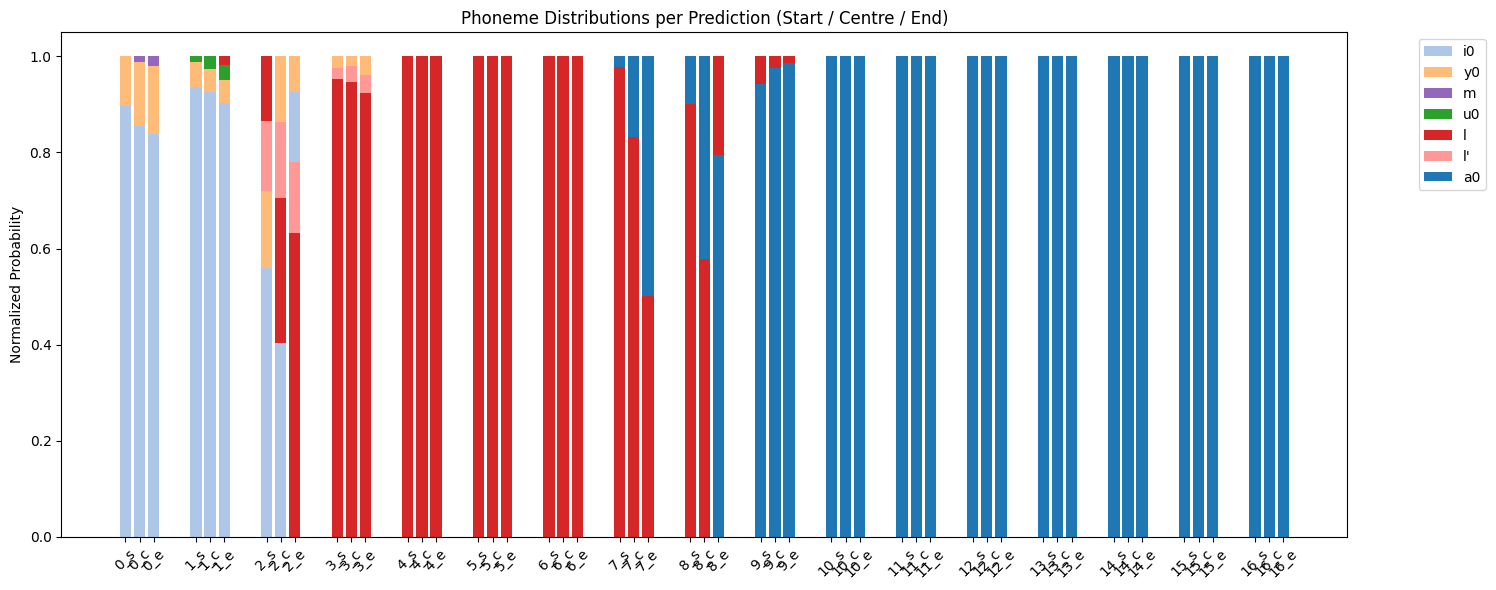

In [17]:
threshold = 0.01

max_examples = 50

palette = sns.color_palette("tab20", len(phoneme_list))
phoneme_colors = {phoneme: palette[i % len(palette)] for i, phoneme in enumerate(phoneme_list)}

fig, ax = plt.subplots(figsize=(15, 6))

bar_width = 0.2
inner_gap = 0.05
group_gap = 0.5

x_ticks = []
x_labels = []

x_pos = 0

for ex_idx in range(min(len(prob_distributions['start']), max_examples)):
#for ex_idx in range(26, 39):
    for j, part in enumerate(['start', 'centre', 'end']):
        dist = prob_distributions[part][ex_idx]
        dist = [(p, v) for p, v in dist if v > threshold]
        total = sum(v for _, v in dist)
        dist = [(p, v / total) for p, v in dist if total > 0]

        bottom = 0
        for phoneme, prob in dist:
            ax.bar(x_pos, prob, width=bar_width, bottom=bottom,
                   color=phoneme_colors[phoneme], label=phoneme)
            bottom += prob

        x_ticks.append(x_pos)
        x_labels.append(f'{ex_idx}_{part[0]}')

        x_pos += bar_width + inner_gap

    x_pos += group_gap

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel("Normalized Probability")
ax.set_title("Phoneme Distributions per Prediction (Start / Centre / End)")

plt.tight_layout()
plt.show()